# Road Accident Prediction And Classification
###### Abdul Wahed and Abrar Hashmi        


### Introduction



## Importing Data and cleaning
- We import three files to perform analysis on this data. This data is consist of three files that are accidents, casualities and vehicles. However, we have one more file which is general information about the traffic count for year 2000 to 2015. We can use general traffic information data for machine learning part.

In [1]:
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#from mpl_toolkits.basemap import Basemap
from sklearn.model_selection import TimeSeriesSplit
plt.style.use('ggplot')
%config InlineBackend.figure_format = 'retina'
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

# Load datasets
accidents = pd.read_csv(
    'Accidents.csv',
    index_col='Accident_Index',
    low_memory=False
)

casualties = pd.read_csv(
    'Casualties.csv',
    on_bad_lines='skip',
    index_col='Accident_Index',
    low_memory=False
)

vehicles = pd.read_csv(
    'Vehicles.csv',
    on_bad_lines='skip',
    index_col='Accident_Index',
    low_memory=False
)

# general_info = pd.read_csv('ukTrafficAADF.csv')

In [3]:
accidents.head()

,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,Day_of_Week,...,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location
Accident_Index,,,,,,,,,,,,,,,,,,,,,
200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,04/01/2005,3,...,0,1,1,2,2,0,0,1,1,E01002849
200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,05/01/2005,4,...,0,5,4,1,1,0,0,1,1,E01002909
200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,06/01/2005,5,...,0,0,4,1,1,0,0,1,1,E01002857
200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,07/01/2005,6,...,0,0,1,1,1,0,0,1,1,E01002840
200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,10/01/2005,2,...,0,0,7,1,2,0,0,1,1,E01002863


In [4]:
accidents = accidents.join(vehicles, how='outer')

## Identifying Missing Values

In this particular dataset, there are two types of missing values '-1' and 'Nan'. We will invesitigate each column with total missing values.
We will not be imputing any mean or median value since the dataset is big enough to perform analysis.

In [5]:
print(accidents.columns)

Index(['Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude',
       'Latitude', 'Police_Force', 'Accident_Severity', 'Number_of_Vehicles',
       'Number_of_Casualties', 'Date', 'Day_of_Week', 'Time',
       'Local_Authority_(District)', 'Local_Authority_(Highway)',
       '1st_Road_Class', '1st_Road_Number', 'Road_Type', 'Speed_limit',
       'Junction_Detail', 'Junction_Control', '2nd_Road_Class',
       '2nd_Road_Number', 'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions',
       'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'LSOA_of_Accident_Location', 'Vehicle_Reference', 'Vehicle_Type',
       'Towing_and_Articulation', 'Vehicle_Manoeuvre',
       'Vehicle_Location-Restricted_Lane', 'Junction_Location',
       'Skidding_and_Overturning', 'Hit_Object_in_Carriageway',
     

In [6]:
# Combine date + time
accidents['Date_time'] = accidents['Date'] + ' ' + accidents['Time']

# Remove -1 values
accidents = accidents[(accidents != -1).all(axis=1)]
casualties = casualties[(casualties != -1).all(axis=1)]

# Convert datetime
accidents['Date_time'] = pd.to_datetime(
    accidents['Date_time'],
    dayfirst=True,
    errors='coerce'
)

# Drop old columns
accidents.drop(['Date', 'Time'], axis=1, inplace=True, errors='ignore')

# Drop missing values
accidents.dropna(inplace=True)

Our dataset is clean to do some analysis. We would be using very few columns to do analysis since the dataset is fairly large.

# Data Visualization

#### The first thing we can do is to find out about accidents time to get intution and some driver's age who are involved in the accident.
- We can find out the number of accidents on the days of a week.
- We can find out about the accidents number using hours of the day.
- Finding out about the age of driver can tell us more about the accidents.

Text(0.5, 0, '0 - Sunday ,  1 - Monday  ,2 - Tuesday , 3 - Wednesday , 4 - Thursday , 5 - Friday , 6 - Saturday')

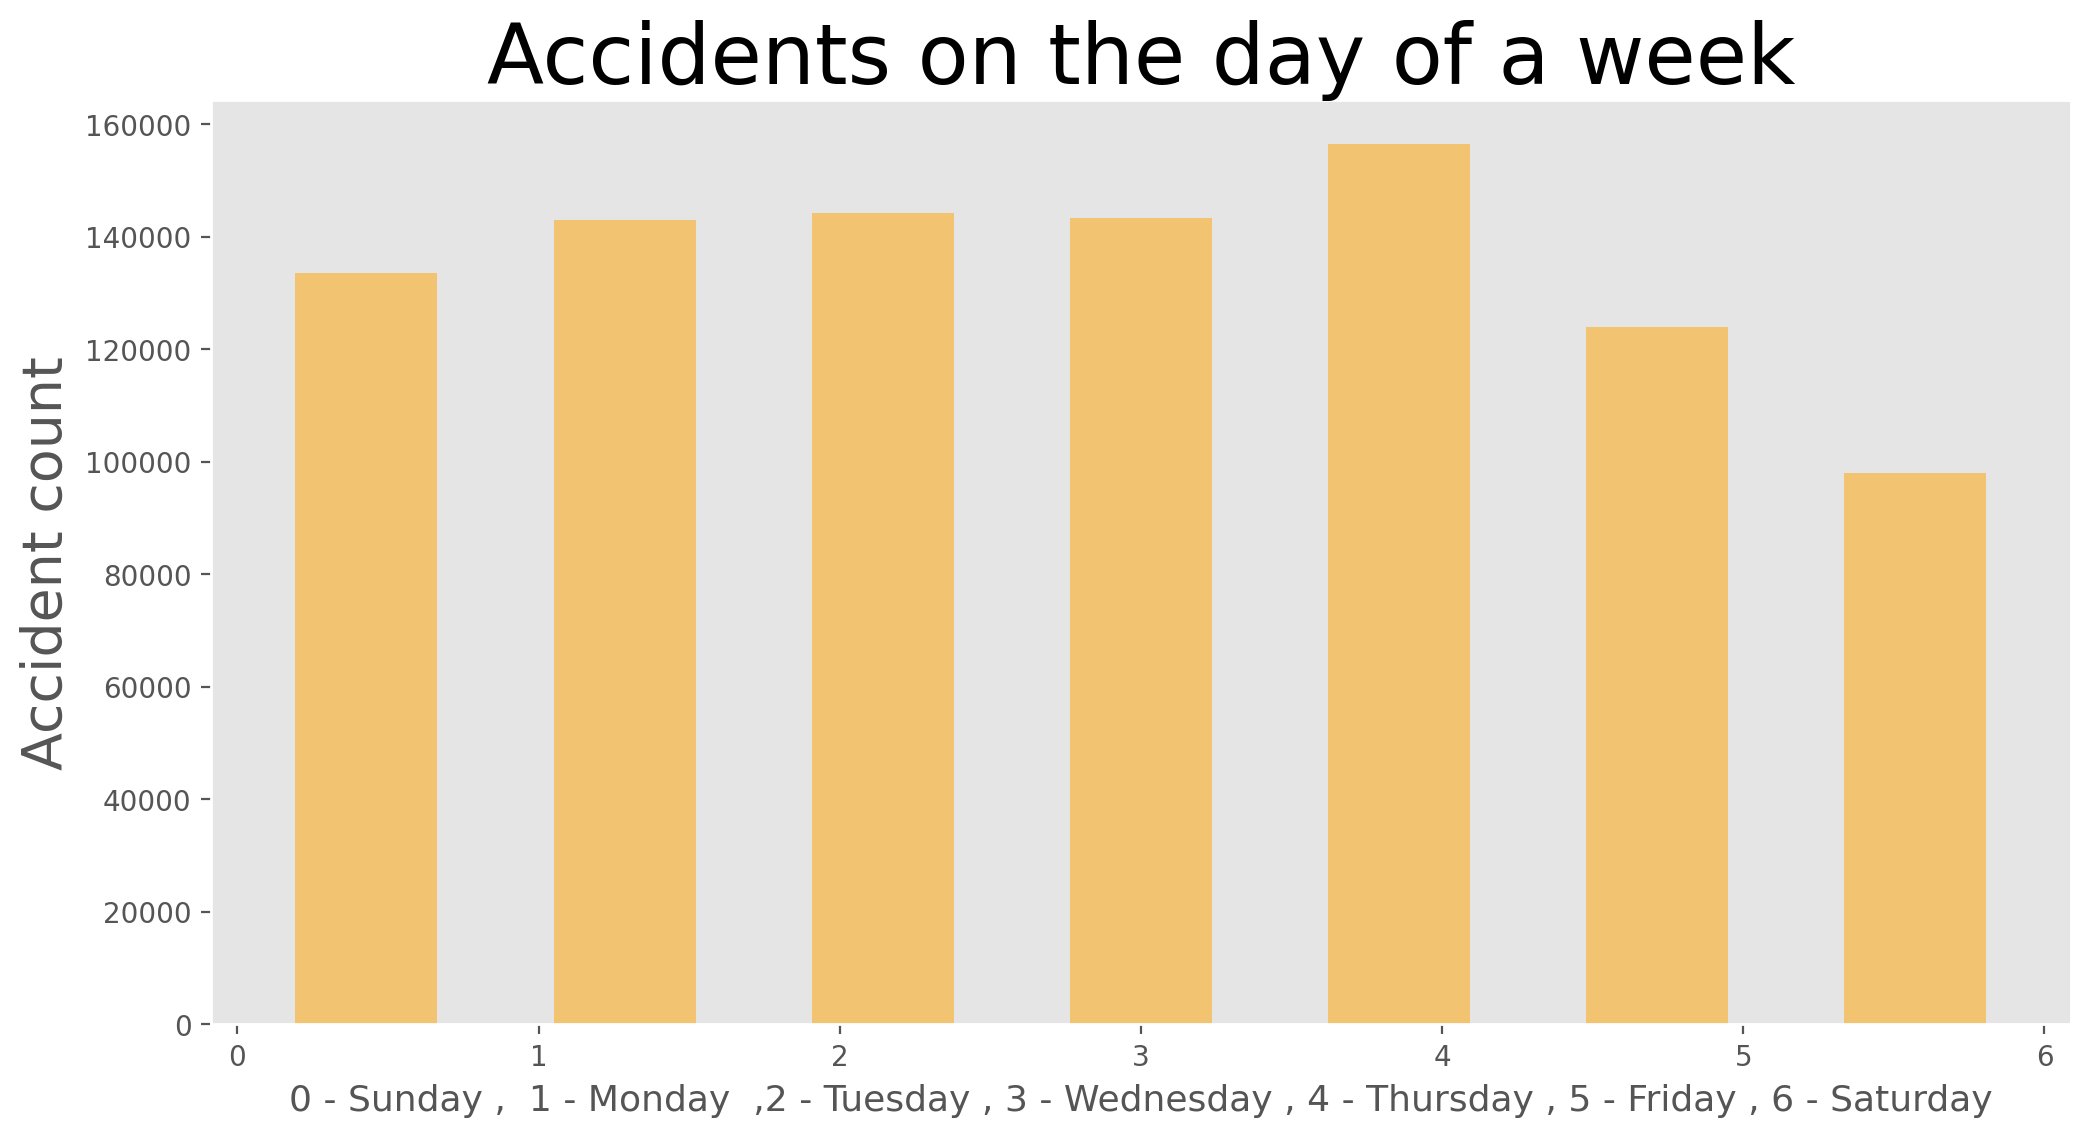

In [7]:
plt.figure(figsize=(12,6))
accidents.Date_time.dt.dayofweek.hist(bins=7,rwidth=0.55,alpha=0.5, color= 'orange')
plt.title('Accidents on the day of a week' , fontsize= 30)
plt.grid(False)
plt.ylabel('Accident count' , fontsize = 20)
plt.xlabel('0 - Sunday ,  1 - Monday  ,2 - Tuesday , 3 - Wednesday , 4 - Thursday , 5 - Friday , 6 - Saturday' , fontsize = 13)

As we can see that thursday has the highest amount of accidents in this dataset from 2005 to 2015. We have to keep in mind that accidents numbers could be depending on traffic amount on particular day.

Text(0, 0.5, 'Accident count')

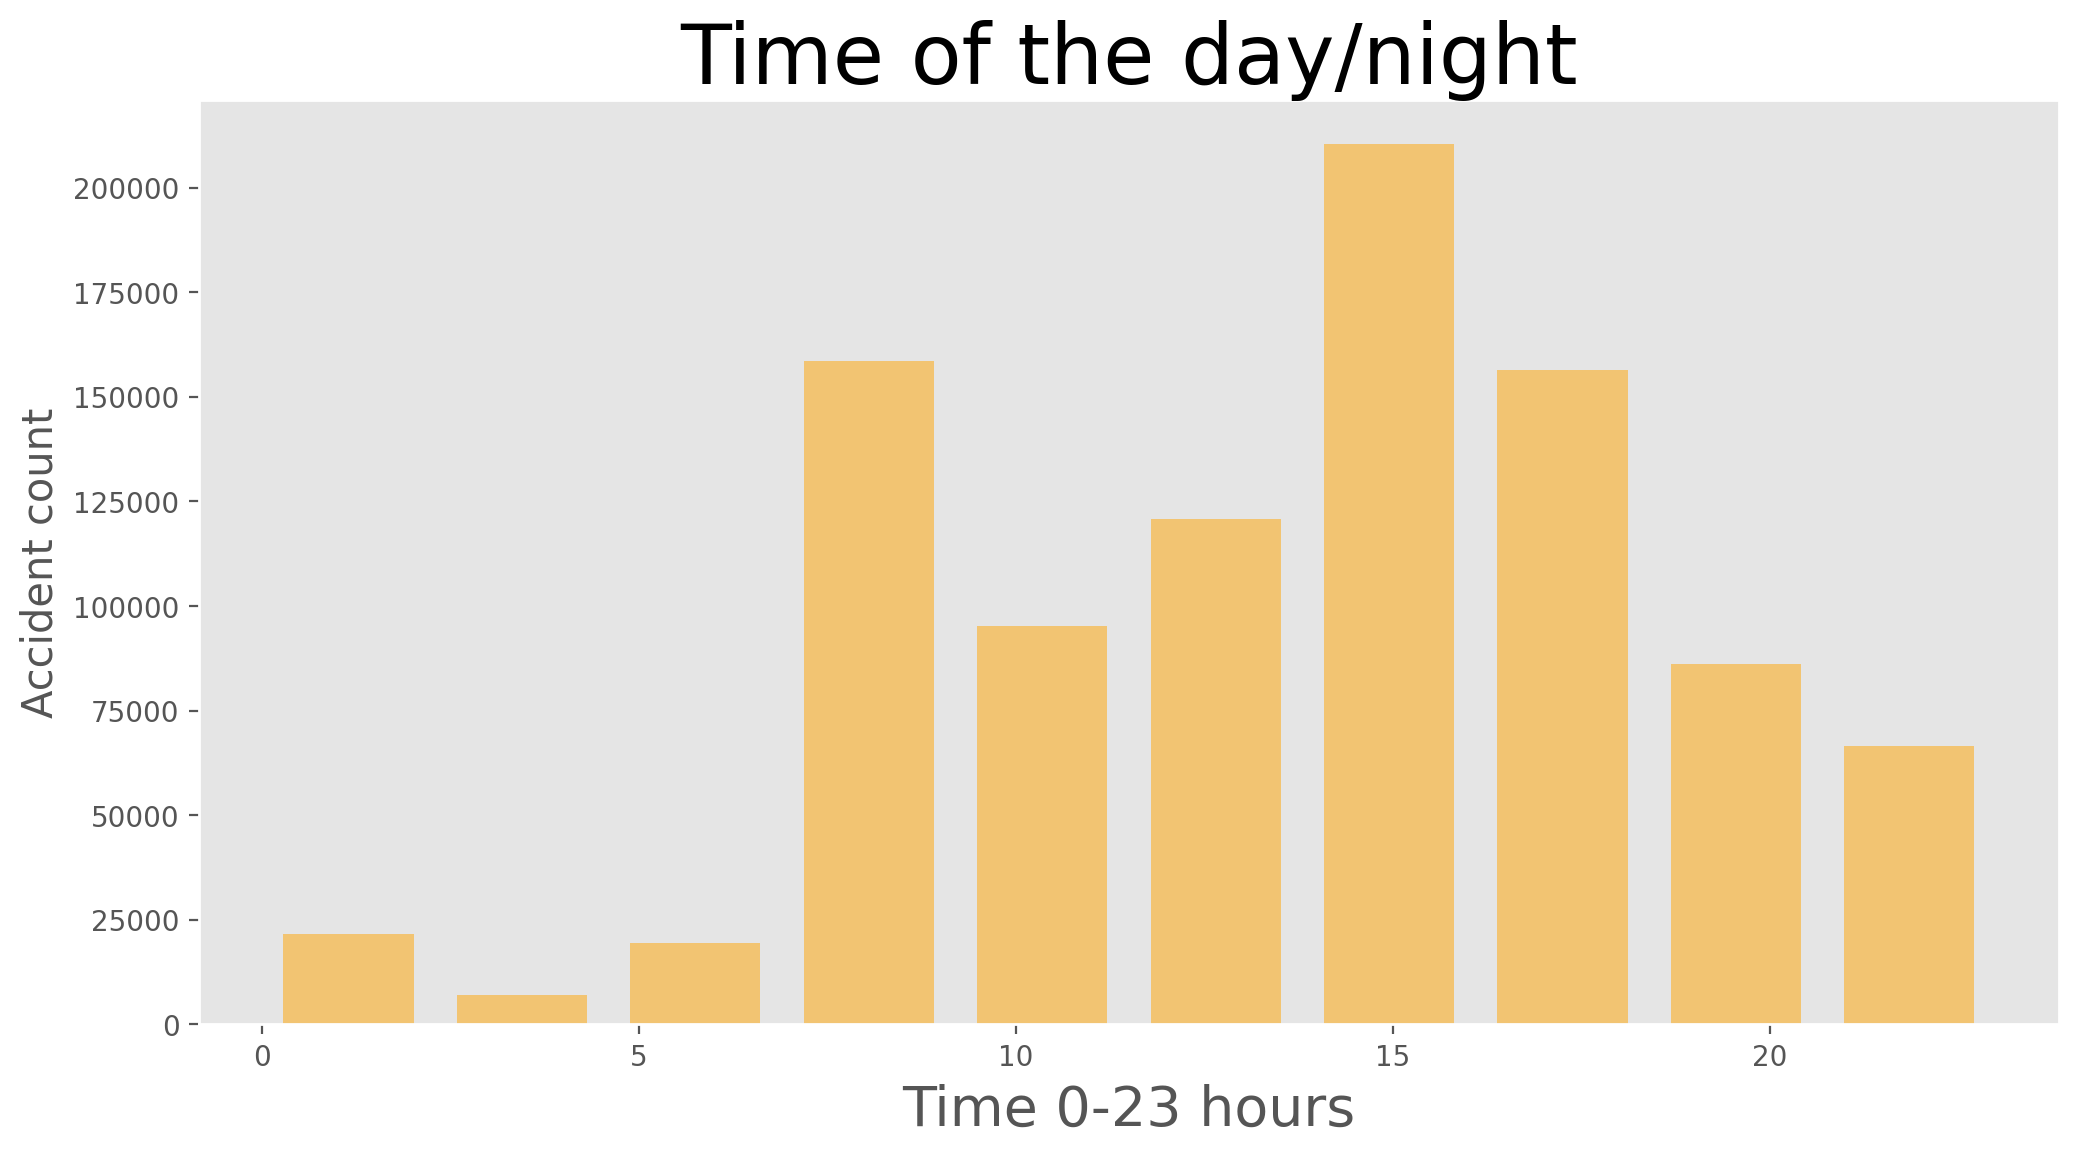

In [8]:
plt.figure(figsize=(12,6))
accidents.Date_time.dt.hour.hist(rwidth=0.75,alpha =0.50, color= 'orange')
plt.title('Time of the day/night',fontsize= 30)
plt.grid(False)
plt.xlabel('Time 0-23 hours' , fontsize = 20)
plt.ylabel('Accident count' , fontsize = 15)


We found out that the most of accidents happened around after noon. We can assume that this time of the day has the most traffic moving such as people leaving from work.


#### Age band of casualities

In this dataset, age band is grouped in 11 different codes. We will create the labels and pass it to the plot as xticks so we can have idea about the bins representation.

Text(0.5, 0, 'Age of Drivers')

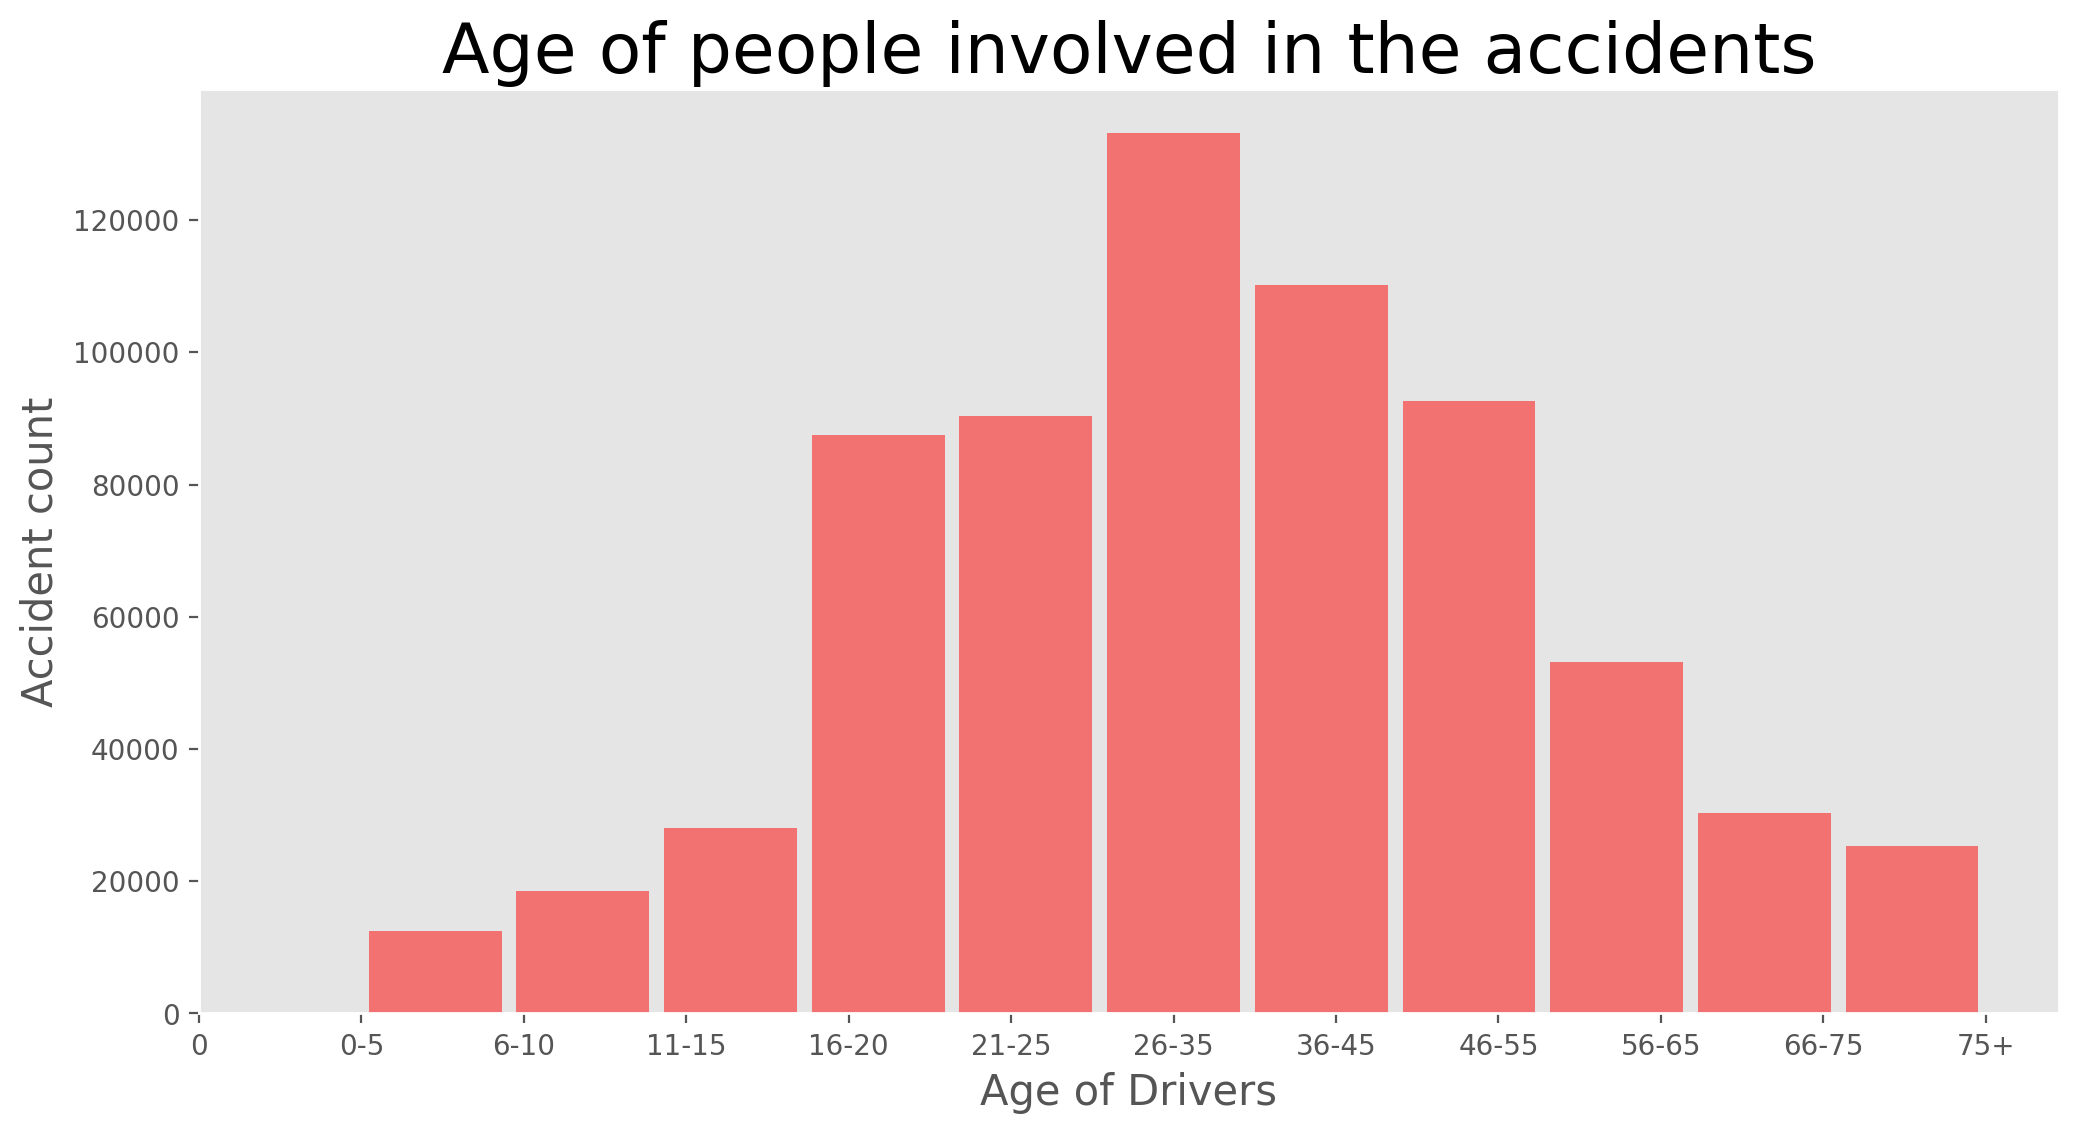

In [9]:
objects = ['0','0-5','6-10','11-15','16-20','21-25','26-35',
          '36-45', '46-55','56-65','66-75','75+']

plt.figure(figsize=(12,6))
casualties.Age_Band_of_Casualty.hist(bins = 11,alpha=0.5,rwidth=0.90, color= 'red',)
plt.title('Age of people involved in the accidents', fontsize = 25)
plt.grid(False)
y_pos = np.arange(len(objects))
plt.xticks(y_pos , objects)
plt.ylabel('Accident count' , fontsize = 15)
plt.xlabel('Age of Drivers', fontsize = 15,)

This is very interesting fact about this dataset. Most of the drivers age is around 225 to 35 who are involved in the accident. However, we do not know the number of drivers with age 25 to 35 on the road compare to other ages. Intutively, I would assume that the driver with age 25 to 35 are more in the number of drivers with different age.

In [11]:
print(len(speed))
print(speed.index)

0
Index([], dtype='int64', name='Speed_limit')


In [12]:
explode = [0] * len(speed)

In [14]:
speed_zone_accidents = accidents.loc[
    accidents['Speed_limit'].isin([20, 30, 40, 50, 60, 70])
]

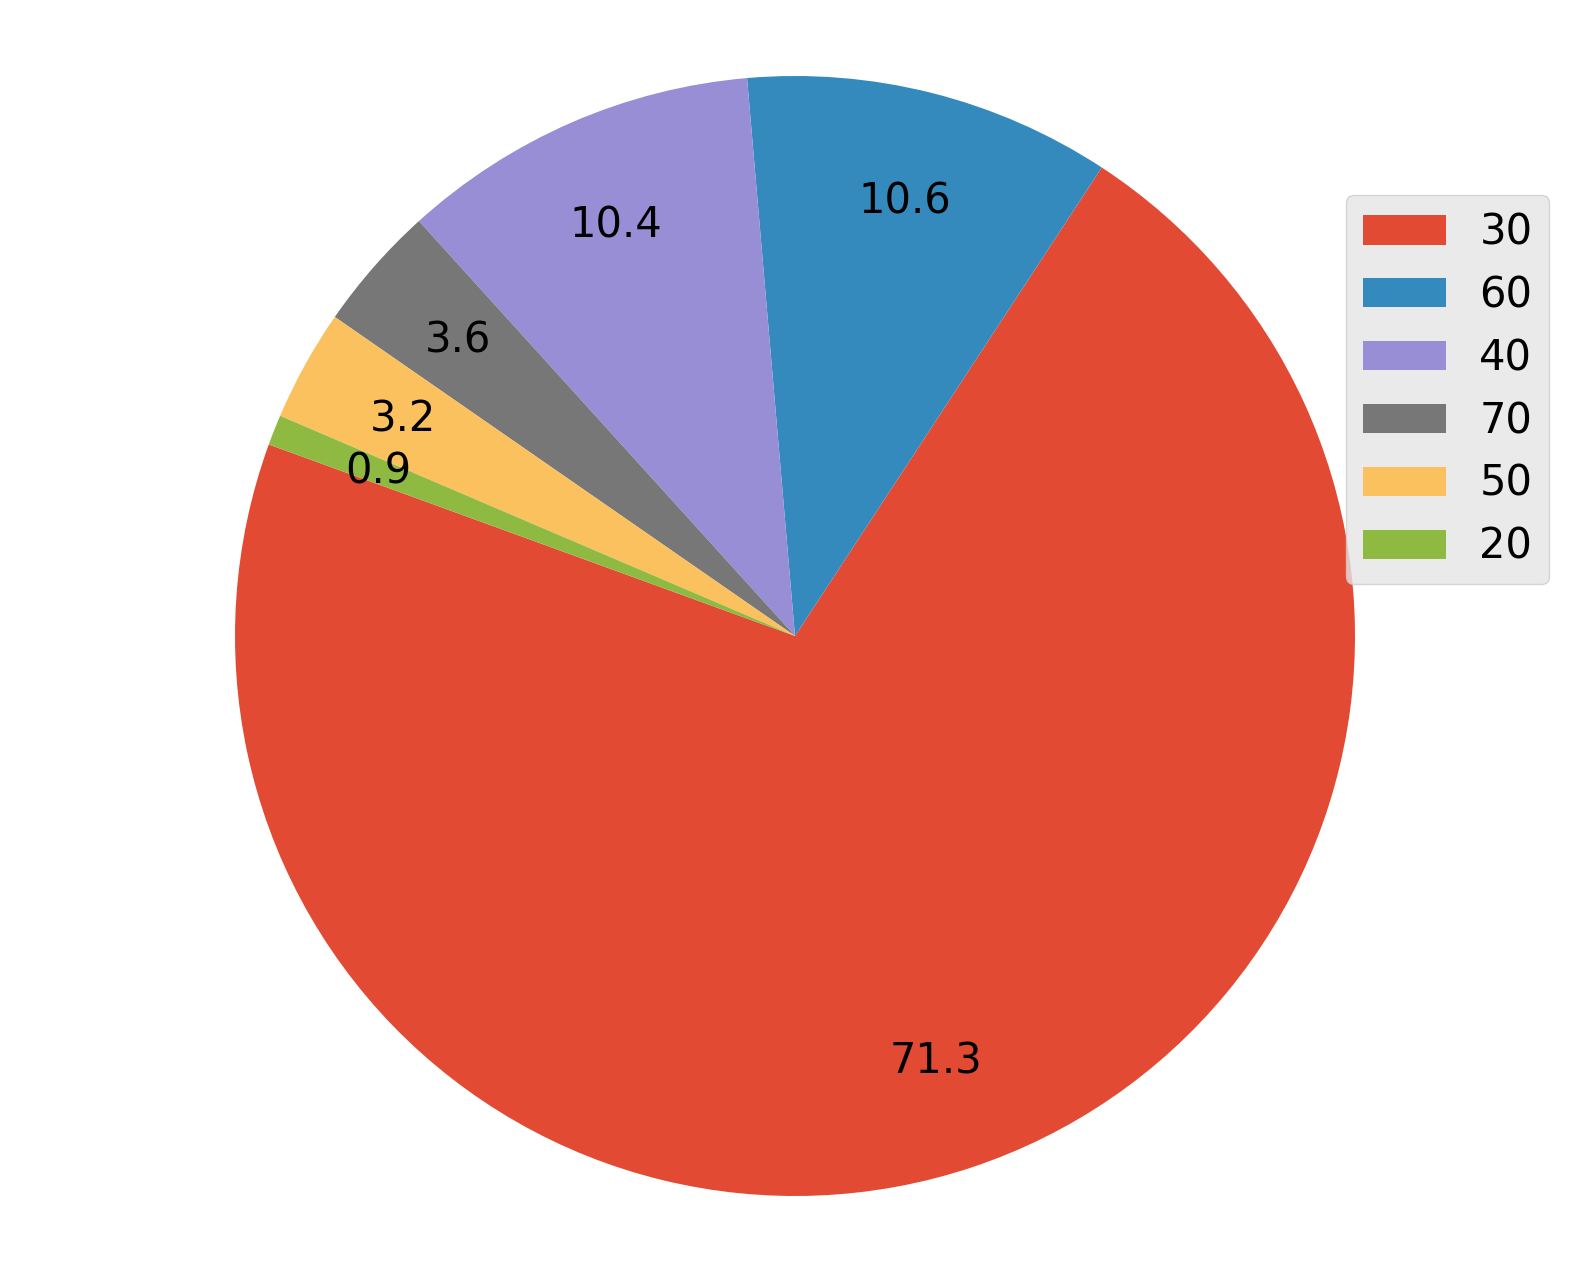

In [15]:
speed_zone_accidents = accidents.loc[
    accidents['Speed_limit'].isin([20, 30, 40, 50, 60, 70])
]

speed = speed_zone_accidents['Speed_limit'].value_counts()

explode = [0] * len(speed)

plt.figure(figsize=(10,8))
plt.pie(speed.values,
        autopct='%.1f',
        pctdistance=0.8,
        labeldistance=1.9,
        explode=explode,
        startangle=160,
        textprops={'fontsize': 15})

plt.axis('equal')

plt.legend(speed.index,
           bbox_to_anchor=(1,0.7),
           loc="center right",
           fontsize=15)

plt.show()

Most of the accidents occured on the road where the speed limit is 30. I was expecting more accidents on highway or major roadways. Some of the accidents could be cause of stop sign, changing lanes or turning into parking lot etc.

## Co-relation between variables

Since our dataset is in numeric values. We can findout correlation between columns.

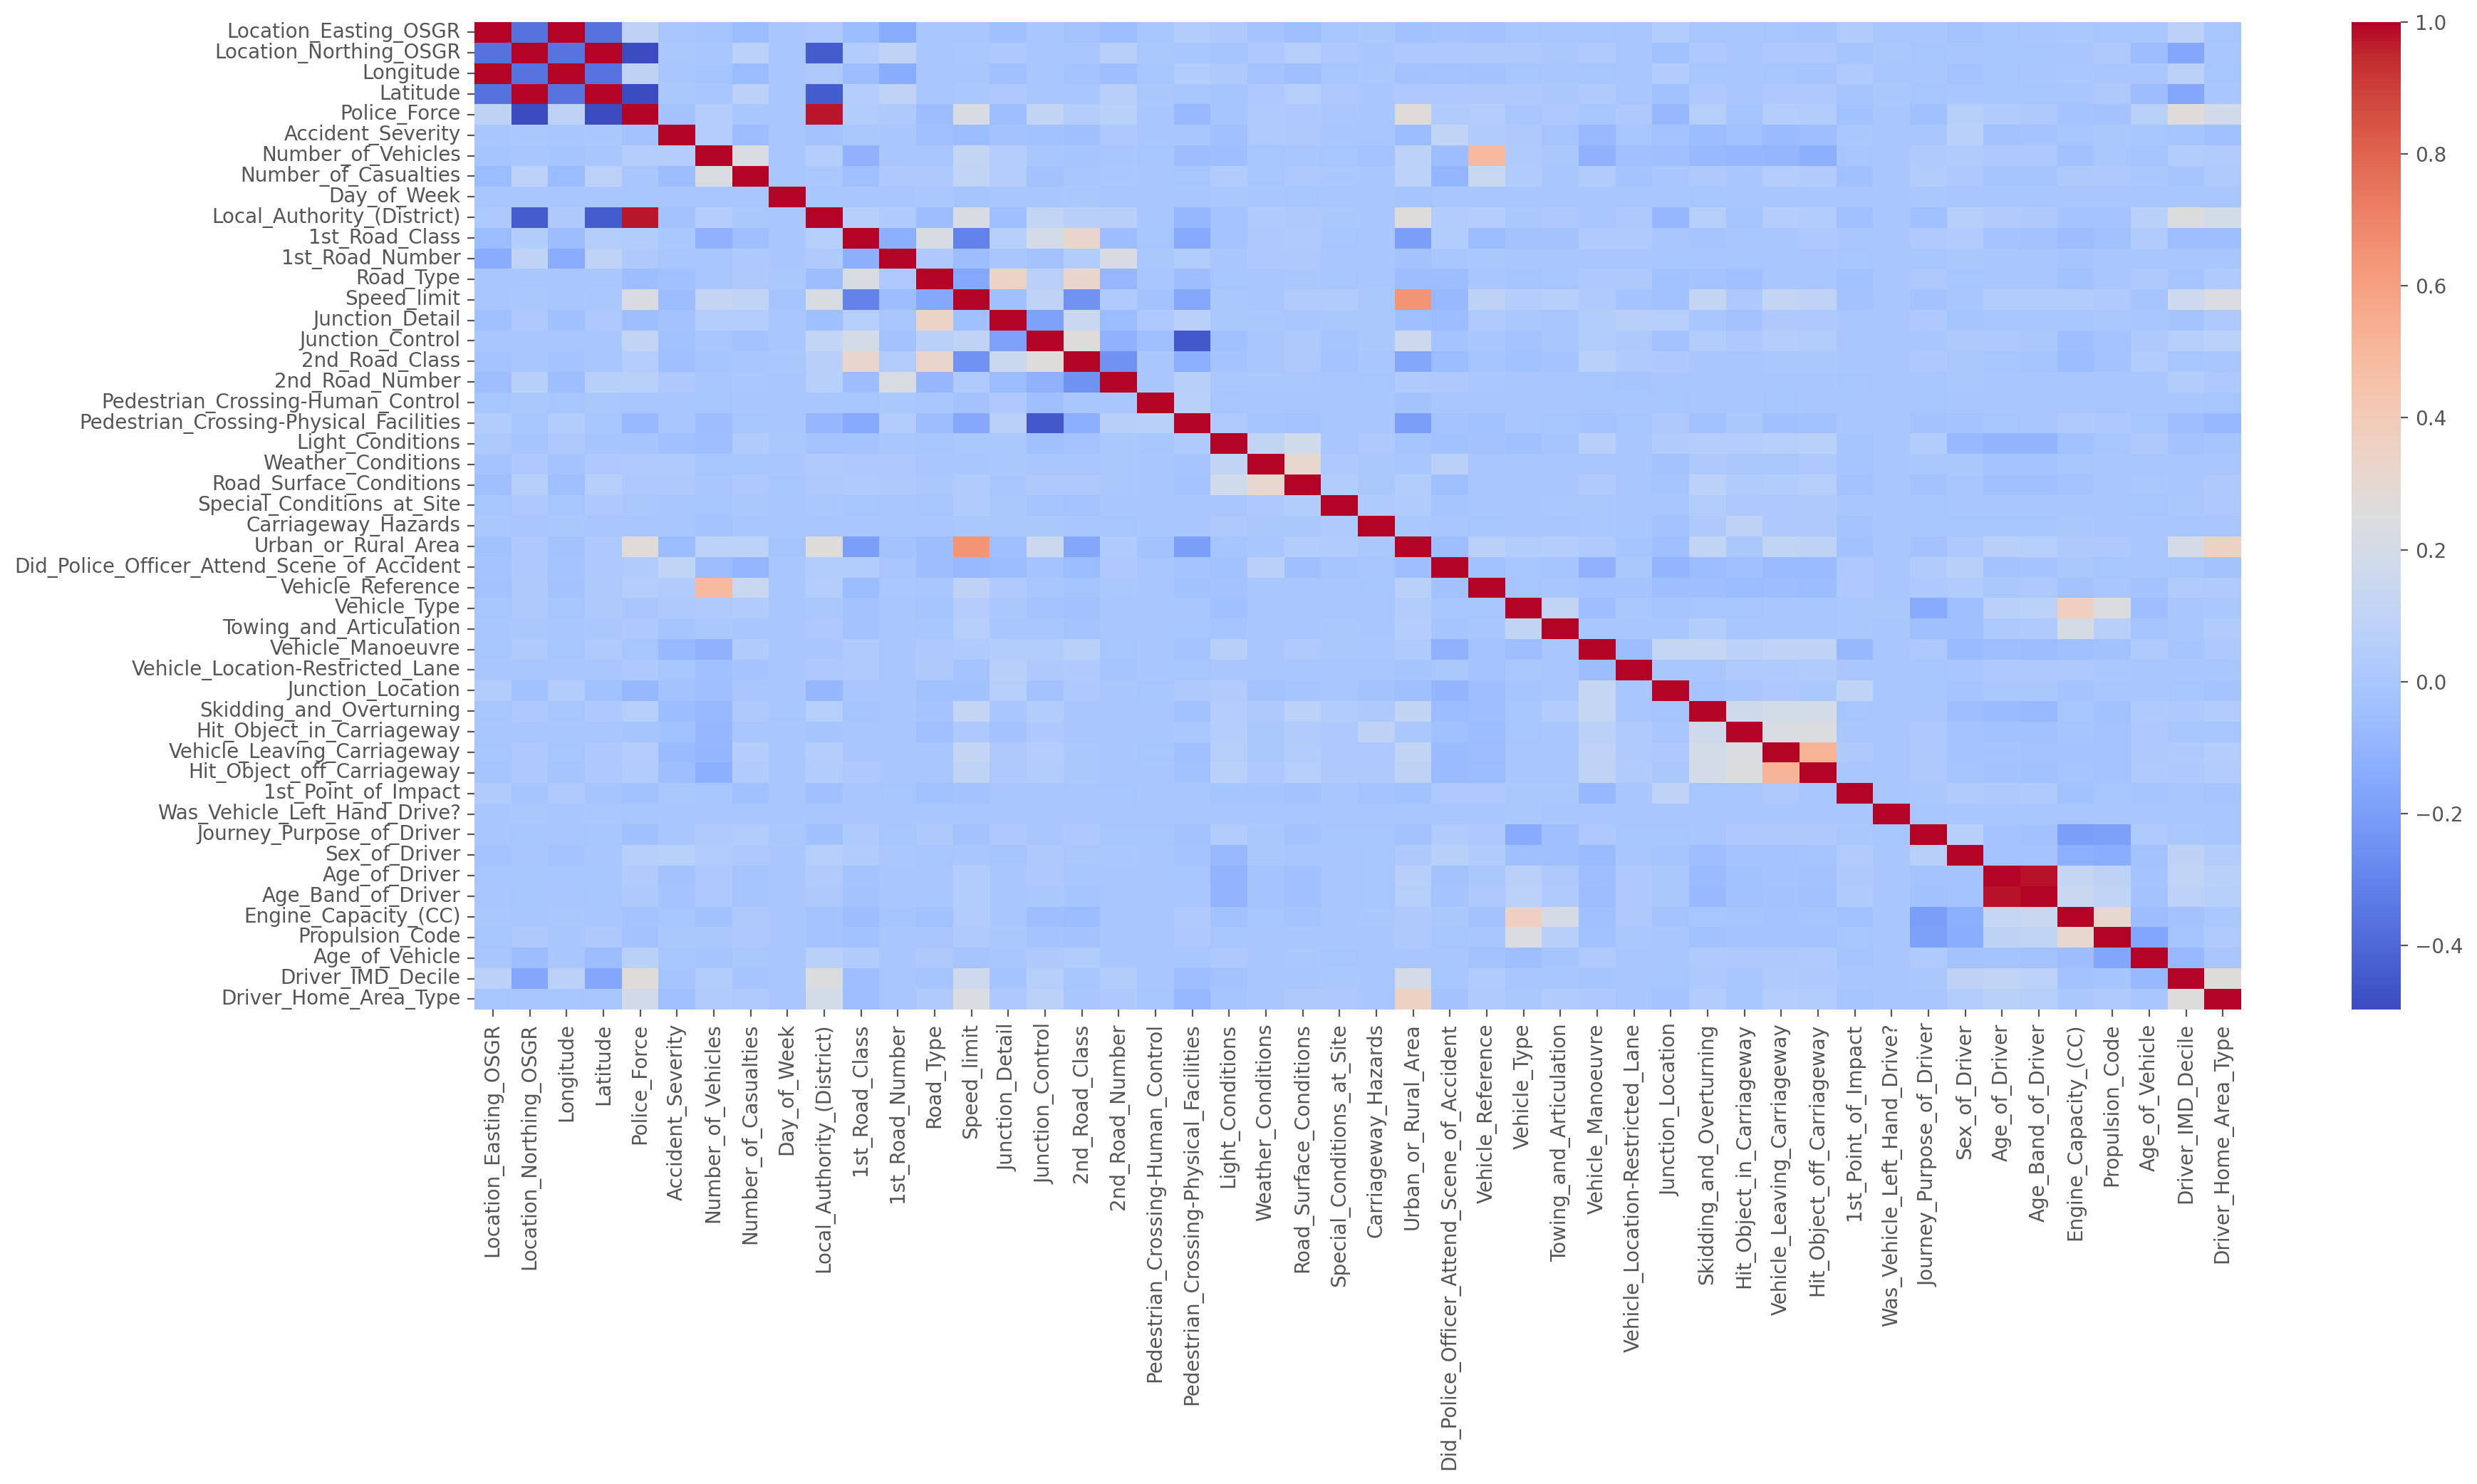

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = accidents.corr(numeric_only=True)

plt.figure(figsize=(20, 9))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

As we see that there is not so much strong correlations between any variables. I was expecting weather condition to be strong correlation with any of the variable. 
- There is only one postiive strong correlation between speed limit and Urban or Rural Area. 

In [17]:
accidents_2014 = accidents[accidents.Date_time.dt.year ==2014]
accidents_2014_01 = accidents_2014[accidents_2014.Accident_Severity == 1]
accidents_2014_02 = accidents_2014[accidents_2014.Accident_Severity == 2]
accidents_2014_03 = accidents_2014[accidents_2014.Accident_Severity == 3]

As we can see that most of fatal accidents happened locally within cities instead on highways. It could be the reason of the traffic is more congested locally than on highways.

## Machine Learning

We will be looking at different columns to figure out predicting about the accidents severity. After we can predict the accident severity, we can make some recommendation to law enforcement for looking into this and be prepared for the future. We can also have more emergency medical services available for those situations.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import log_loss

## Normalize the Data
There are few columns that we will standarize, so it would not effect negatively on our machine learning algorithms. Age of driver is from 18 to 88 in the dataset and we can normalize it. Also, the age of vehicle is also from 0 to 100 and it can skew the performance of your machine learning algorithm and we will normalize this predictor too.

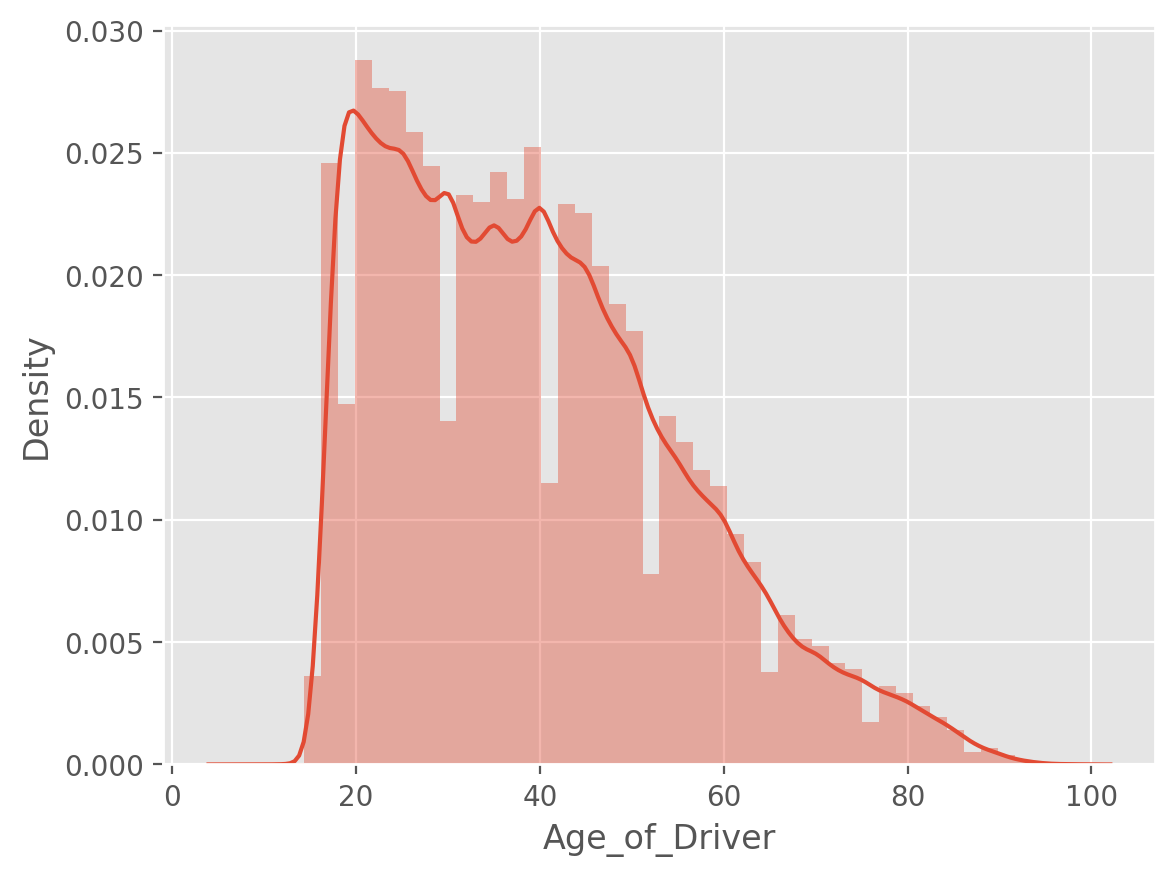

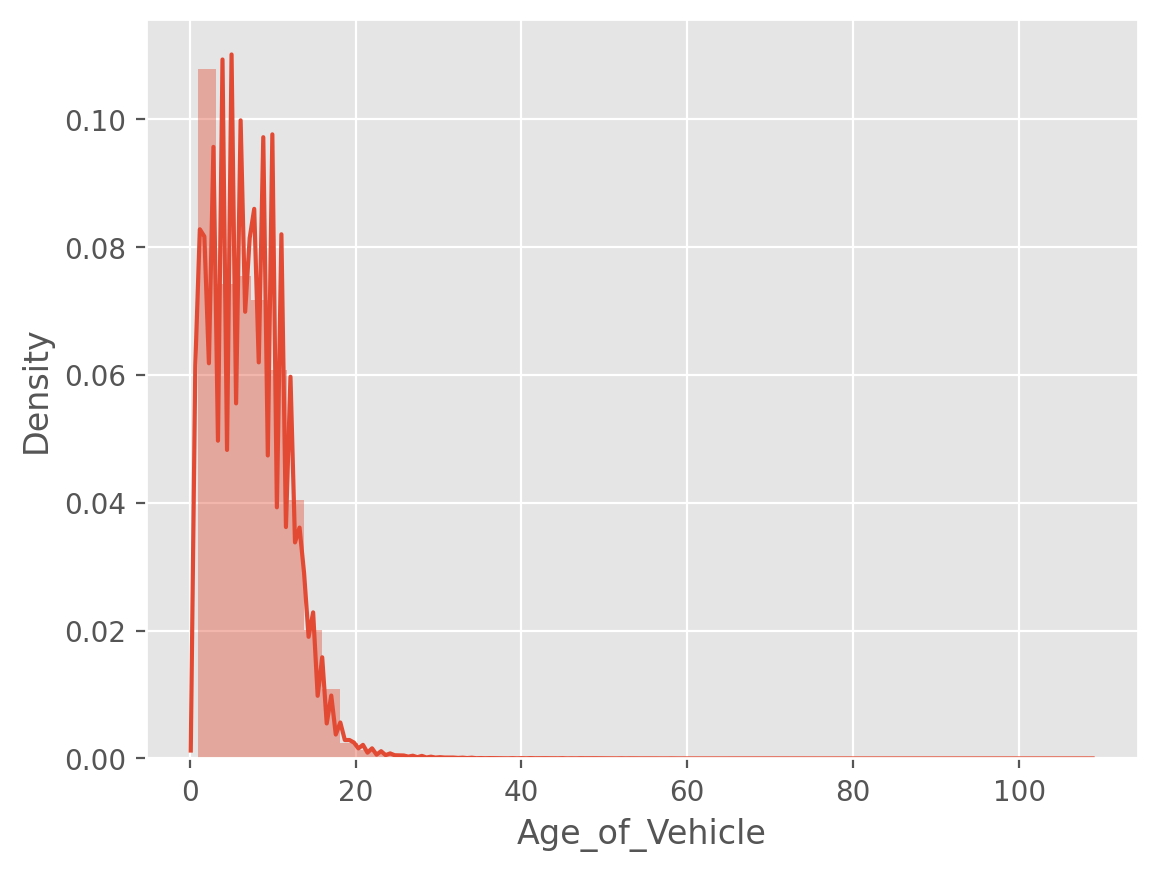

<Figure size 640x480 with 0 Axes>

In [19]:
sns.distplot(accidents['Age_of_Driver']);
fig = plt.figure()
sns.distplot(accidents['Age_of_Vehicle']);
fig = plt.figure()

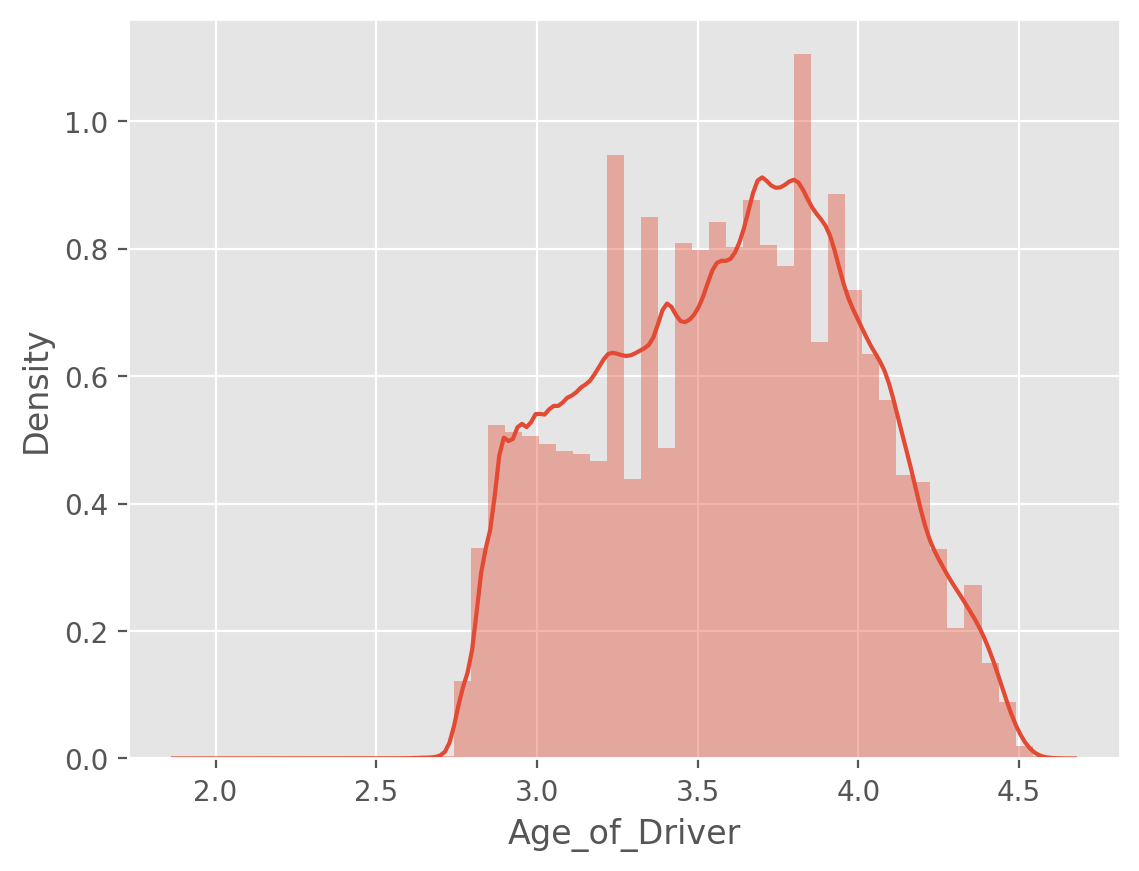

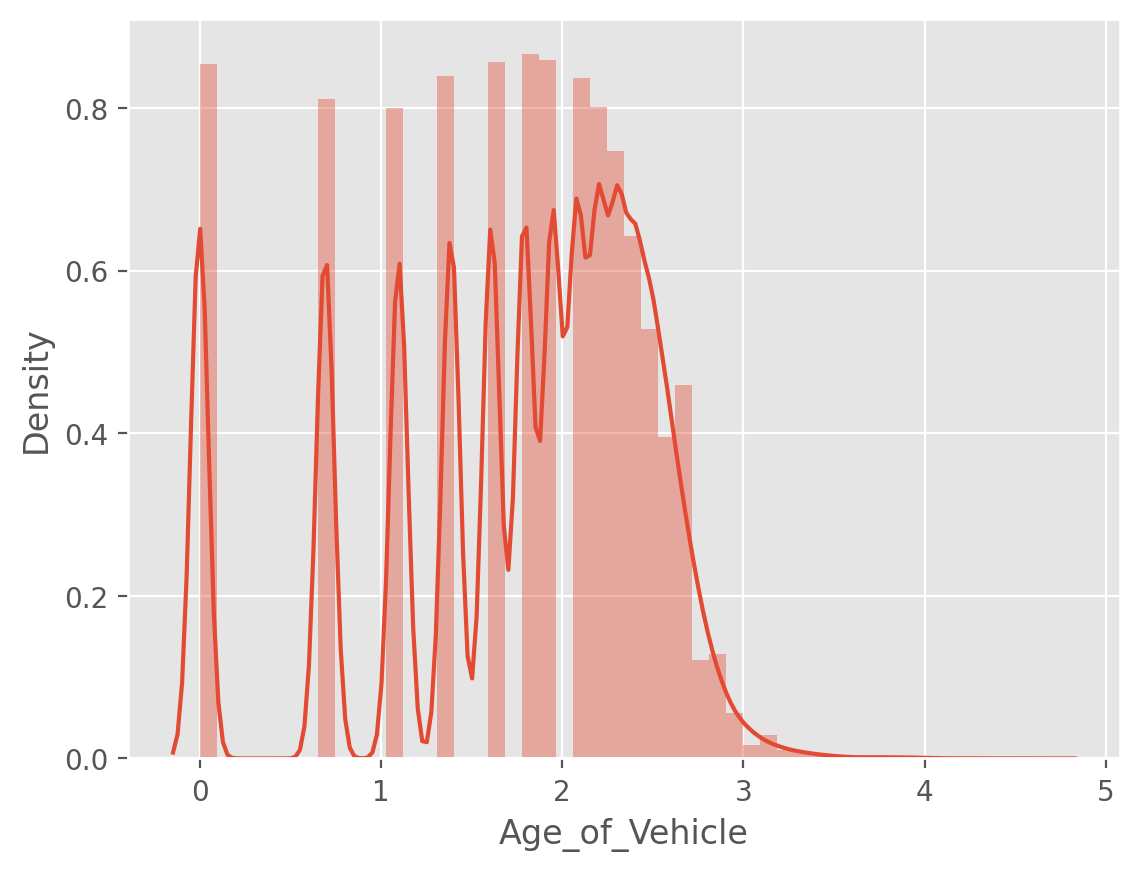

<Figure size 640x480 with 0 Axes>

In [20]:
accidents['Age_of_Driver'] = np.log(accidents['Age_of_Driver'])
accidents['Age_of_Vehicle'] = np.log(accidents['Age_of_Vehicle'])
sns.distplot(accidents['Age_of_Driver']);
fig = plt.figure()
sns.distplot(accidents['Age_of_Vehicle']);
fig = plt.figure()

## Spliting the data into training data and test data
We will also consider few features as predictors for machine learning algorithm.

In [21]:
from sklearn.model_selection import train_test_split

# Feature selection
accident_ml = accidents[['Did_Police_Officer_Attend_Scene_of_Accident',
                         'Age_of_Driver',
                         'Vehicle_Type',
                         'Age_of_Vehicle',
                         'Engine_Capacity_(CC)',
                         'Day_of_Week',
                         'Weather_Conditions',
                         'Road_Surface_Conditions',
                         'Light_Conditions',
                         'Sex_of_Driver',
                         'Speed_limit']]

# Check data
accident_ml.head()

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    accident_ml.values,
    accidents['Accident_Severity'].values,
    test_size=0.20,
    random_state=99
)

## Random Forest

In [22]:
random_forest = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1
)

In [23]:
random_forest = RandomForestClassifier(
    n_estimators=50,
    max_features='sqrt',
    n_jobs=-1
)

In [24]:
random_forest = RandomForestClassifier(
    n_estimators=50,
    max_samples=0.7,   # use only 70% data per tree
    n_jobs=-1
)

In [25]:
random_forest = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    max_features='sqrt',
    max_samples=0.7,
    n_jobs=-1,
    random_state=42
)

In [ ]:
# random_forest = RandomForestClassifier(n_estimators=200)
# random_forest.fit(X_train,y_train)
# Y_pred = random_forest.predict(X_test)
# random_forest.score(X_test, y_test)
# acc_random_forest1 = round(random_forest.score(X_test, y_test) * 100, 2)

# sk_report = classification_report(
#     digits=6,
#     y_true=y_test, 
#     y_pred=Y_pred)
# print("Accuracy" , acc_random_forest1)
# print(sk_report)
# pd.crosstab(y_test, Y_pred, rownames=['Actual'], colnames=['Predicted'], margins=True)

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd

# FAST + OPTIMIZED MODEL
random_forest = RandomForestClassifier(
    n_estimators=50,       # reduced trees
    max_depth=10,          # limit tree depth
    max_features='sqrt',   # fewer features per split
    max_samples=0.7,       # use 70% data per tree
    n_jobs=-1,             # use all CPU cores
    random_state=42
)

# SAME FLOW AS YOUR ORIGINAL CODE
random_forest.fit(X_train, y_train)

Y_pred = random_forest.predict(X_test)

acc_random_forest1 = round(random_forest.score(X_test, y_test) * 100, 2)

sk_report = classification_report(
    digits=6,
    y_true=y_test, 
    y_pred=Y_pred
)

print("Accuracy", acc_random_forest1)
print(sk_report)

print(pd.crosstab(y_test, Y_pred, 
                  rownames=['Actual'], 
                  colnames=['Predicted'], 
                  margins=True))

Accuracy 88.25
              precision    recall  f1-score   support

           1   0.000000  0.000000  0.000000      1366
           2   0.470588  0.001540  0.003070     20777
           3   0.882689  0.999844  0.937621    166321

    accuracy                       0.882540    188464
   macro avg   0.451092  0.333795  0.313564    188464
weighted avg   0.830859  0.882540  0.827796    188464

Predicted   2       3     All
Actual                       
1          10    1356    1366
2          32   20745   20777
3          26  166295  166321
All        68  188396  188464


In [27]:
random_forest = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    max_features='sqrt',
    max_samples=0.7,
    n_jobs=-1,
    class_weight='balanced',   # ⭐ IMPORTANT
    random_state=42
)

In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=200)

## Logistic Regression 

In [30]:
lr = LogisticRegression()
# Fit the model on the trainng data.
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
sk_report = classification_report(
    digits=6,
    y_true=y_test, 
    y_pred=y_pred)
print("Accuracy", round(accuracy_score(y_pred, y_test)*100,2))
print(sk_report)
pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'], margins=True)

Accuracy 88.25
              precision    recall  f1-score   support

           1   0.000000  0.000000  0.000000      1366
           2   0.000000  0.000000  0.000000     20777
           3   0.882511  0.999982  0.937581    166321

    accuracy                       0.882492    188464
   macro avg   0.294170  0.333327  0.312527    188464
weighted avg   0.778823  0.882492  0.827423    188464



Predicted,1,3,All
Actual,,,
1,0,1366,1366
2,1,20776,20777
3,3,166318,166321
All,4,188460,188464


## Decision Tree

In [31]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
Y_pred = decision_tree.predict(X_test)
acc_decision_tree1 = round(decision_tree.score(X_test, y_test) * 100, 2)
sk_report = classification_report(
    digits=6,
    y_true=y_test, 
    y_pred=Y_pred)
print("Accuracy", acc_decision_tree1)
print(sk_report)
### Confusion Matrix 
pd.crosstab(y_test, Y_pred, rownames=['Actual'], colnames=['Predicted'], margins=True)

Accuracy 78.01
              precision    recall  f1-score   support

           1   0.021115  0.028551  0.024276      1366
           2   0.139746  0.168937  0.152961     20777
           3   0.888415  0.862663  0.875350    166321

    accuracy                       0.780138    188464
   macro avg   0.349759  0.353383  0.350862    188464
weighted avg   0.799592  0.780138  0.789542    188464



Predicted,1,2,3,All
Actual,,,,
1,39,266,1061,1366
2,307,3510,16960,20777
3,1501,21341,143479,166321
All,1847,25117,161500,188464


As we can see that Logistic regression did pretty well in terms of number. If we look carefully at the confusion matrix. We can definitely tell that Decision tree algorithm did much better. It predicted more fatal and serious injuries as true positive. The accuracy score is lower compare to another algorithm because other algorithm predicted majority of slightly accidents and those numbers are really high overall in the dataset. Confusion matrix helps us to understand what algorithm actually worked better in terms of looking at all different prediction of each class.

# Hyperparameters tuning for the models


### Logistic Regression with Hyperparameter tuning


In [34]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=200,
    class_weight='balanced',
    n_jobs=-1   # ⭐ speed boost
)

In [35]:
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [36]:
y_pred = lr.predict(X_test)

In [37]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2))
print(classification_report(y_test, y_pred))

Accuracy: 55.94
              precision    recall  f1-score   support

           1       0.02      0.55      0.03      1366
           2       0.14      0.20      0.16     20777
           3       0.91      0.60      0.73    166321

    accuracy                           0.56    188464
   macro avg       0.35      0.45      0.31    188464
weighted avg       0.81      0.56      0.66    188464



In [38]:
import pandas as pd

print(pd.crosstab(y_test, y_pred,
                  rownames=['Actual'],
                  colnames=['Predicted'],
                  margins=True))

Predicted      1      2       3     All
Actual                                 
1            758    214     394    1366
2           6556   4141   10080   20777
3          40292  25492  100537  166321
All        47606  29847  111011  188464


As we can see that Logistic regression still didn't predict two classes of accident severity out of 3. Even though it is showing the 86.2% accuracy. 

### Decision Tree hyperparameters tuning

All we are going to do is find the best values for mininum sample leaf and maximum features to get the best score.

In [39]:
decision_tree = DecisionTreeClassifier(min_samples_leaf=12, max_features=4)
decision_tree.fit(X_train, y_train)
Y_pred = decision_tree.predict(X_test)
acc_decision_tree1 = round(decision_tree.score(X_test, y_test) * 100, 2)
sk_report = classification_report(
    digits=6,
    y_true=y_test, 
    y_pred=Y_pred)
print("Accuracy", acc_decision_tree1)
print(sk_report)
### Confusion Matrix 
pd.crosstab(y_test, Y_pred, rownames=['Actual'], colnames=['Predicted'], margins=True)

Accuracy 87.88
              precision    recall  f1-score   support

           1   0.111111  0.000732  0.001455      1366
           2   0.306926  0.029648  0.054073     20777
           3   0.884971  0.992064  0.935462    166321

    accuracy                       0.878778    188464
   macro avg   0.434336  0.340815  0.330330    188464
weighted avg   0.815636  0.878778  0.831525    188464



Predicted,1,2,3,All
Actual,,,,
1,1,78,1287,1366
2,1,616,20160,20777
3,7,1313,165001,166321
All,9,2007,186448,188464


We really didn't see much difference in Accident severity 1 and 2. However we did improve the accuracy of Accident severity 3. It jumped the accuracy from 75.1% to 85.8%.

## Feature importance
We can use Sklearn's random forest library to find out the most important features. We will be plotting in  ascending order so we know what features are most important to predict the accident severity.

In [41]:
random_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [44]:
print(accident_ml.columns)

Index(['Did_Police_Officer_Attend_Scene_of_Accident', 'Age_of_Driver',
       'Vehicle_Type', 'Age_of_Vehicle', 'Engine_Capacity_(CC)', 'Day_of_Week',
       'Weather_Conditions', 'Road_Surface_Conditions', 'Light_Conditions',
       'Sex_of_Driver', 'Speed_limit'],
      dtype='str')


In [45]:
feature_names = accident_ml.columns

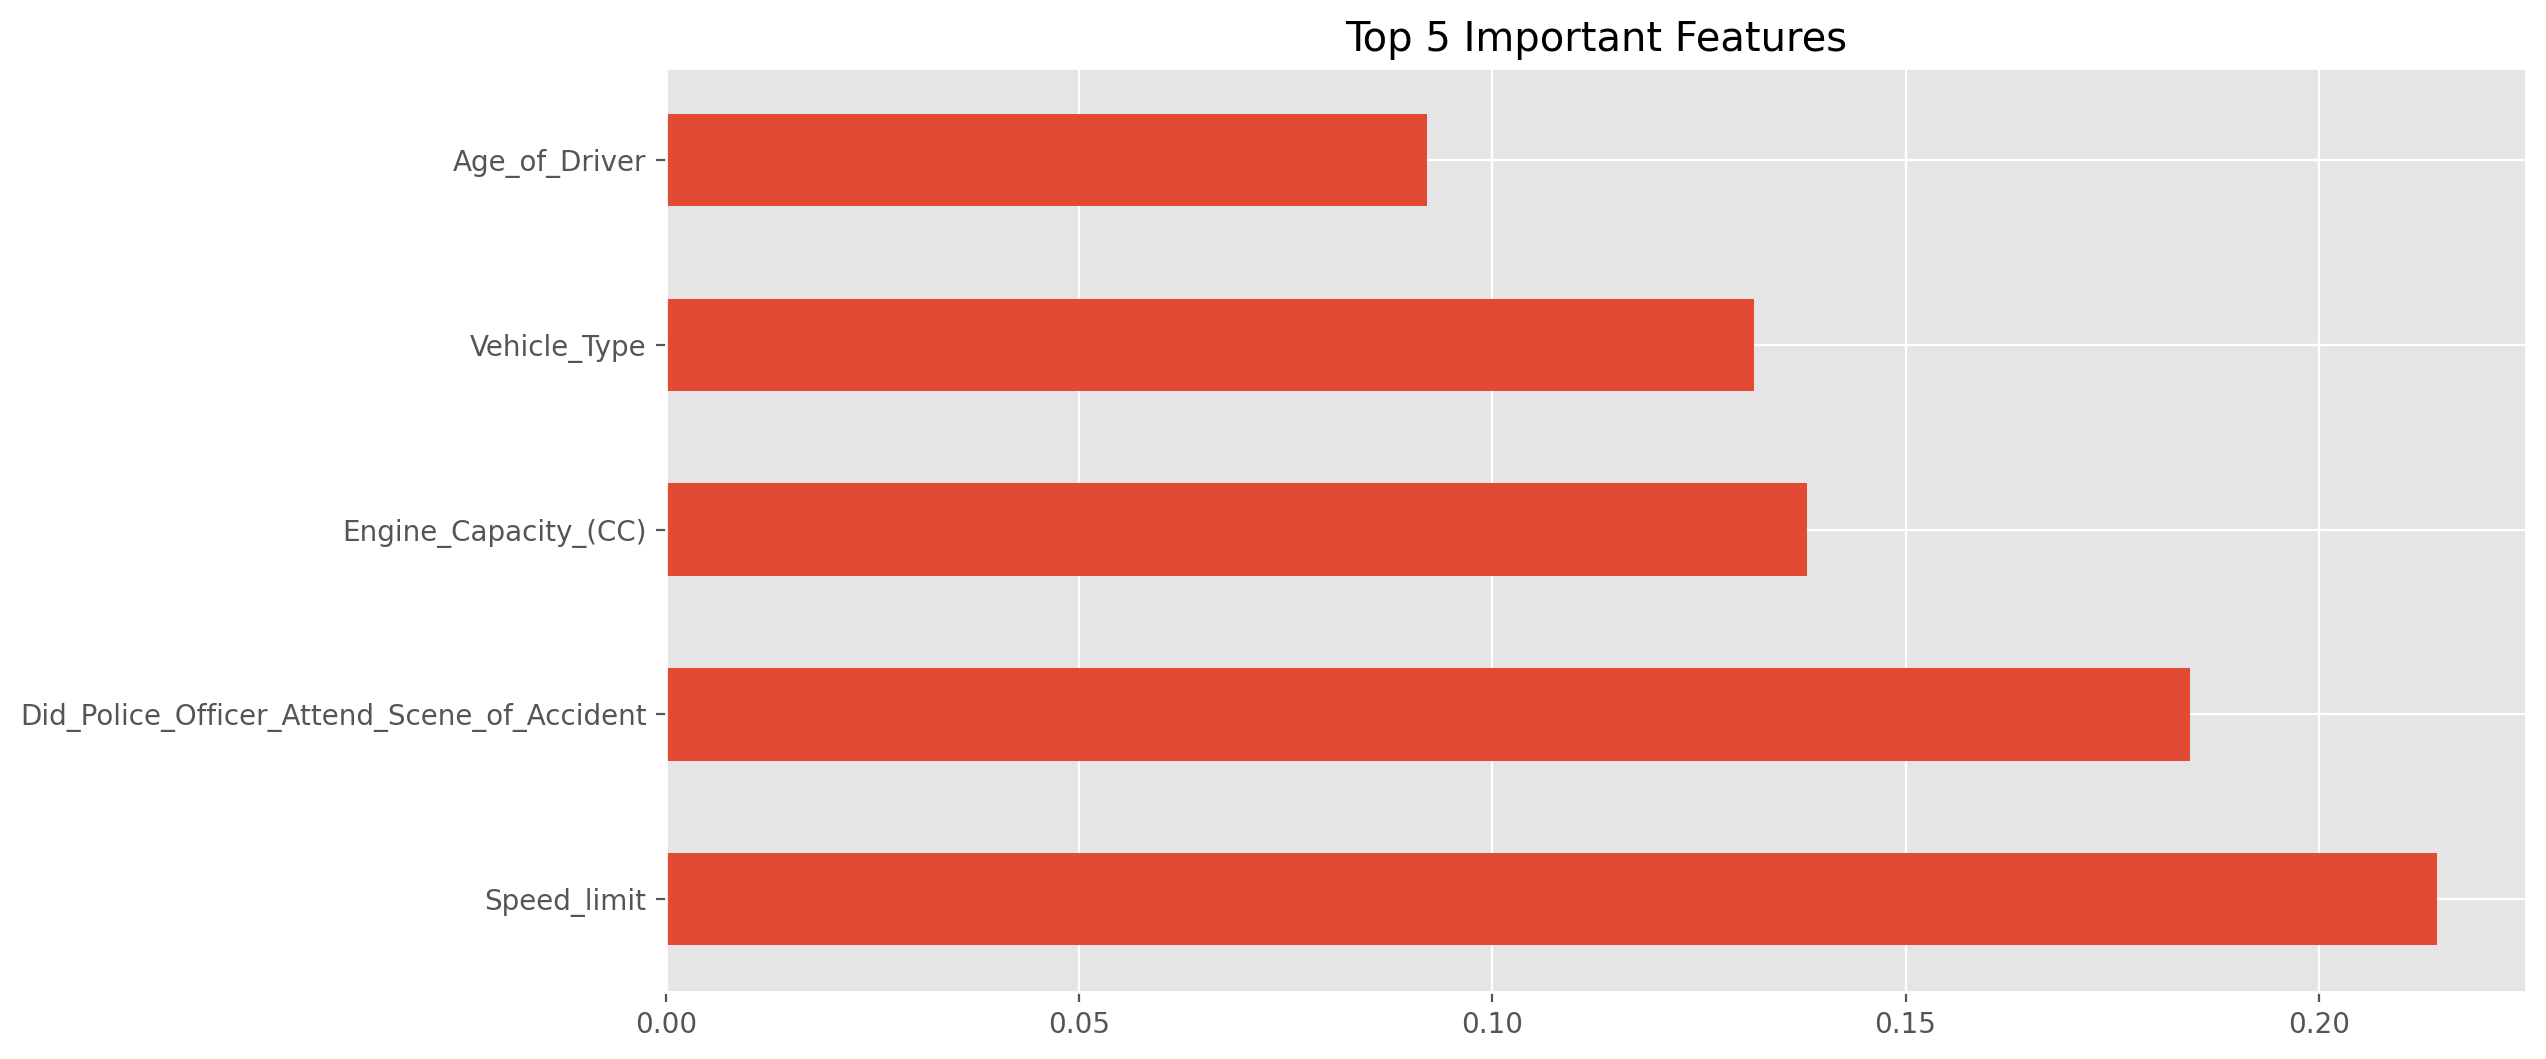

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(12,6))

feat_importances = pd.Series(
    random_forest.feature_importances_,
    index=feature_names
)

feat_importances.nlargest(5).plot(kind='barh')

plt.title("Top 5 Important Features")
plt.show()

In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50],
    'max_depth': [10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(n_jobs=-1),
    param_grid,
    cv=2
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ier(n_jobs=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10], 'n_estimators': [50]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and c

Random forest took lots of time to tune the hyperparameter. Most of the algorithm works well only with default values except decision tree.

## Conclusion


#### Machine Learning Conclusion


#### Recommendation for Public .